# Non-incremental online learning of parallelizable RNN

In [50]:
# @title Loading data

from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/My Drive/Colab Notebooks/sp500.csv'

import pandas as pd
import numpy as np

data = pd.read_csv(file_path)
data = np.array(data)

#data reshaping

data = data[:,1:]
data = np.array(data, dtype=float)

#standardization

mean_value = np.mean(data, axis=0)
std_dev = np.std(data, axis=0)
data = (data - mean_value) / std_dev

data = data.T

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [51]:
# @title Loading optuna

import matplotlib.pyplot as plt
import numpy as np
import scipy.stats
import scipy.signal
import networkx as nx
import csv

!pip install optuna
import optuna

Data shape: (503, 387)


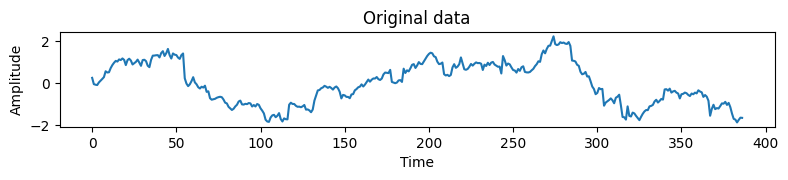

In [52]:
# @title visualization of data

import matplotlib.pyplot as plt
#import numpy as np
import scipy.stats
import scipy.signal
import datetime
import networkx as nx
import csv


print('Data shape:',data.shape)

plt.figure(figsize=(8, 3))

plt.subplot(2, 1, 1)
plt.plot(data[4,:])
plt.title('Original data')
plt.xlabel('Time')
plt.ylabel('Amplitude')


plt.tight_layout()
plt.show()


In [53]:
# @title Definition of Reservoir computing (without ``Class" setting!!)

####################
#input weight matrix
####################

def input_matrix(N_x,seed_value,input_scale,dim):

# Separate integer and decimal portions
    seed_int_low = int(np.floor(seed_value))
    seed_int_high = int(np.ceil(seed_value))
    fraction = seed_value - seed_int_low

# Random number generation for integer part
    np.random.seed(seed_int_low)
    random_matrix_low = np.random.uniform(-input_scale, input_scale, (N_x, dim))
    np.random.seed(seed_int_high)
    random_matrix_high = np.random.uniform(-input_scale, input_scale, (N_x, dim))

# Linear interpolation allows random seed values to correspond continuously to the matrix
    interpolated_matrix = (1 - fraction) * random_matrix_low + fraction * random_matrix_high

    return interpolated_matrix

##############################
# Recurrent weight matrix
##############################

def generate_random_binary_matrix(N_x, dim, density, seed_value_binary):

    num_ones = int(N_x*dim * density)

    matrix = np.zeros(N_x*dim, dtype=int)

    np.random.seed(seed_value_binary)

    ones_indices = np.random.choice(N_x*dim, num_ones, replace=False)
    matrix[ones_indices] = 1

    return matrix.reshape((N_x, dim))


def recurrent_matrix(N_x, density, rho,seed_value):

# Separate random seed value into integer and decimal portions
        seed_int_low = int(np.floor(seed_value))
        seed_int_high = int(np.ceil(seed_value))
        fraction = seed_value - seed_int_low

        random_binary_matrix_low   = generate_random_binary_matrix(N_x, N_x, density, seed_int_low)
        random_binary_matrix_high  = generate_random_binary_matrix(N_x, N_x, density, seed_int_high)
        interpolated_binary_matrix = \
         (1 - fraction) * random_binary_matrix_low + fraction * random_binary_matrix_high


# Separate integer and decimal portions
        seed_int_low = int(np.floor(seed_value))
        seed_int_high = int(np.ceil(seed_value))
        fraction = seed_value - seed_int_low

# Generate nonzero elements as random numbers following a uniform distribution
        rec_scale = 1.0

# Random number generation based on integer part
        np.random.seed(seed_int_low)
        random_matrix_low = np.random.uniform(-rec_scale, rec_scale, (N_x, N_x))
        np.random.seed(seed_int_high)
        random_matrix_high = np.random.uniform(-rec_scale, rec_scale, (N_x, N_x))

# Linear interpolation allows random seed values and matrices to correspond continuously
        interpolated_matrix = (1 - fraction) * random_matrix_low + fraction * random_matrix_high

        W = interpolated_binary_matrix * interpolated_matrix

        # Calculation of spectral radius
        eigv_list = np.linalg.eigh(W)[0]
        sp_radius = np.max(np.abs(eigv_list))

        # Scaling to a specified spectral radius rho
        W *= rho / sp_radius
        return W

#############################
# reservoir state vector
#############################

def Reservoir(x_in,x,W,alpha,bias_scale):

        Wbias = np.ones(len(x_in))
        Wbias = Wbias * bias_scale

        x = (1.0 - alpha) * x \
                 + alpha * np.tanh(np.dot(W, x)+Wbias \
                 + x_in)
        return x

############################
#Ridge Regression and  Output Weight Matrix
############################

def Ridge(d, x, X_XT,D_XT):

        x = np.reshape(x, (-1, 1))
        d = np.reshape(d, (-1, 1))
        X_XT += np.dot(x, np.transpose(x))
        D_XT += np.dot(d, np.transpose(x))
        return X_XT, D_XT

def get_Wout_opt(X_XT,D_XT,N_x,beta):

        Wout_opt = np.linalg.solve((X_XT + beta * np.identity(N_x)).T, D_XT.T)
        Wout_opt=Wout_opt.T

        return Wout_opt

###################
#Definition of batch learning (convexity)
###################

def train(train_U,train_D, x, T_train,Win,W,N_x,dim,alpha,discard_len,bias_scale):


    X_XT          = np.zeros((N_x, N_x))
    D_XT          = np.zeros((dim, N_x))
    x_special_vec = np.zeros((train_U.shape[0],N_x))

    for m in range(train_U.shape[0]):

        x = np.zeros(N_x)

        for n in range(T_train):

            # reservoir state vector
            x = Reservoir(np.dot(Win,train_U[m,n,:]),x,W,alpha,bias_scale)

            # teacher data
            d = train_D[m,n,:]


            if n > discard_len:  # discard the first part of the data
                 X_XT, D_XT = Ridge(d, x, X_XT, D_XT)

        x_special_vec[m,:] = x

    return X_XT, D_XT,x_special_vec


########################
#induction formula for creating estimated data
########################

def run(test_U,x,Win,W,Wout,alpha,T_test,bias_scale):


    Y_pred = []
    y = test_U[0,:]


    for n in range(T_test):

        x = Reservoir(np.dot(Win,y),x,W,alpha,bias_scale)
        y_pred = np.dot(Wout, x)
        Y_pred.append(y_pred)
        y = y_pred

    return np.array(Y_pred)

In [54]:
# @title Def of model selection（using Optuna）

%%time

from optuna.trial import FrozenTrial
from optuna.trial import TrialState
from datetime import datetime
import os

####################################
#indicator function

def sign_indicator(x):
    if x > 0:
        return 1
    elif x < 0:
        return -1
    else:
        return 0

def sign_onezero(x):
    if x > 0:
        return 1
    elif x < 0:
        return 0
    else:
        return 0
####################################

def heaviside_ratio(A, B):
    product = A * B
    # heaviside(x, 0): x > 0 → 1, x == 0 → 0, x < 0 → 0
    heaviside = np.heaviside(product, 0)
    ratio = np.mean(heaviside)
    return ratio

####################################


# def objection function
def objective(trial):
    lag = trial.suggest_int("lag", max_lag, max_lag)
    dim = trial.suggest_int("dim", max_dim, max_dim)
    N_x = trial.suggest_int("N_x", Node, Node)                #Initially fixed here
    beta = trial.suggest_float("beta", 0.0001, 0.0001)
    density = trial.suggest_float("density", 0.01, 1)
    input_scale = trial.suggest_float("input_scale", 0, 1.5)
    rho = trial.suggest_float("rho", 0, 1.5)
    alpha = trial.suggest_float("alpha", 0, 1)
    seed_value = trial.suggest_float("seed_value", 0, 100)
    bias_scale = trial.suggest_float("bias_scale", -1.5, 1.5)

    #starting test time

    T_0 = T_train + lag * dim

    #determine input and recurrent weight matrices

    Win= input_matrix(N_x,seed_value,input_scale,dim)
    W = recurrent_matrix(N_x, density, rho,seed_value)

    #initialization

    data_delay_train = np.zeros((impl_set.shape[0],T_train+1,dim), dtype=float)
    test_Y           = np.zeros((impl_set.shape[0],T_test))
    test_D           = np.zeros((impl_set.shape[0],T_test))

##########################################
#Convert training data to a delay coordinate system


    for i in range(dim):

        data_delay_train[:,:,i] = impl_set[:,T_0-T_train-i*lag:T_0-i*lag+1] # i*lag Step-delayed time series


# Initialization of training data

    train_U = np.zeros((impl_set.shape[0],T_train,dim), dtype=float)
    train_D = np.zeros((impl_set.shape[0],T_train,dim), dtype=float)

#Input/output of training data

    train_U = data_delay_train[:,:T_train,:]
    train_D = data_delay_train[:,1:T_train+1,:]

##The last time data of the training data output must overlap with the test data!

#Ridge
    X_XT          = np.zeros((N_x, N_x))
    D_XT          = np.zeros((dim, N_x))
    x_special_vec = np.zeros((train_U.shape[0],N_x))

    X_XT, D_XT,_ = train(train_U,train_D,np.zeros(N_x),T_train, \
                                  Win, W, N_x, dim, alpha,discard_len,bias_scale)

# Generate output weight matrix

    Wout= None
    Wout= get_Wout_opt(X_XT, D_XT,N_x,beta)

###############
    data_delay_test         = np.zeros((T_test+1,dim), dtype=float)
    tentative_test_Y        = np.zeros((T_test,dim))
    data_delay_train_resvec = np.zeros((impl_set.shape[0],T_train+1,dim), dtype=float)
    updown_pred             = np.zeros((impl_set.shape[0]))
    updown_ans              = np.zeros((impl_set.shape[0]))

###############
#Convert training data to a delay coordinate system (to generate reservoir state vec)



    for i in range(dim):

        data_delay_train_resvec[:,:,i] = impl_set[:,T_0-T_train-i*lag:T_0-i*lag+1] # i*lag step delayed time series

# Initialization of training data

    train_U = np.zeros((impl_set.shape[0],T_train,dim), dtype=float)
    train_D = np.zeros((impl_set.shape[0],T_train,dim), dtype=float)

#Input/output of training data

    train_U[:,:,:] = data_delay_train_resvec[:,:T_train,:]
    train_D[:,:,:] = data_delay_train_resvec[:,1:T_train+1,:]

##The last time data of the training data output must overlap with the test data!

#Ridge
    X_XT = np.zeros((N_x, N_x))
    D_XT = np.zeros((dim, N_x))
    x_special = np.zeros(N_x)

    _, _,x_special_vec = train(train_U,train_D,np.zeros(N_x),T_train, Win, W, N_x, dim, alpha,discard_len,bias_scale)




#######################
#Convert test data to a delay coordinate system

    for j in range (impl_set.shape[0]):

        for i in range(dim):

            data_delay_test[:,i] = impl_set[j,T_0-i*lag:
                                            T_0+T_test-i*lag+1] # i*lag step delayed time series


  #Generate estimated data


        tentative_test_Y[:,:] = run(data_delay_test[:T_test,:],x_special_vec[j,:], \
                                      Win,W,Wout,alpha,T_test,bias_scale)
        test_Y[j,:] = tentative_test_Y[:,0]
        test_D[j,:] = data_delay_test[1:T_test+1,0]


########################
#up or down

        updown_pred[j] = sign_indicator(test_Y[j,T_test-1]-data_delay_test[0,0])
        updown_ans[j] = sign_indicator(test_D[j,T_test-1]-data_delay_test[0,0])

    return  heaviside_ratio(updown_pred, updown_ans)

CPU times: user 44 µs, sys: 0 ns, total: 44 µs
Wall time: 49.6 µs


In [55]:
# @title Implement: Bayesian optimization of Reservoir

%%time


T_train      = 60   # Training period
T_test       = 5    # Forecast period
discard_len  = 15   # Number of steps not learned at the beginning (not important)
initial_time = 200  # Starting time


n_trials    = 30    # Number of times to test with optuna (generate accuracy for this number of times)


Node       = 30     # Reservoir Node
max_lag    = 1      # Maximum of lag for delay coordinate
max_dim    = 2      # Maximum of dimension for delay coordinate


MAX_TRIALS = 10     # Repeat the same thing while shifting each one step to produce robust result

###############################

print("data.shape:",data.shape)
print("data length from initial_time:",data[:,initial_time:].shape[1])
print("requirement of data length for one train-test:",T_train+max_lag*max_dim+2*T_test+1)

###############################



from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score


mean_score     = []
score          = []

mean_accuracy  = []
mean_f1        = []
mean_precision = []
mean_recall    = []
accuracy  = []
f1        = []
precision = []
recall    = []


for trial in range(MAX_TRIALS):
    print(f"Trial {trial + 1}/{MAX_TRIALS}")

    impl_set = data[:,initial_time+trial:initial_time+T_train+max_lag*max_dim+2*T_test+1+trial]

    def stop_callback(study, trial):
        if study.best_value > 0.63:
            study.stop()


    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials, callbacks=[stop_callback])

    print("Best trial:")
    trial = study.best_trial
    print(f"  'params': {trial.params},")
    print(f"  'value': {trial.value},")

    lag  = trial.params["lag"]
    dim  = trial.params["dim"]
    N_x  = trial.params["N_x"]
    beta = trial.params["beta"]
    density = trial.params["density"]
    input_scale = trial.params["input_scale"]
    rho         = trial.params["rho"]
    alpha       = trial.params["alpha"]
    seed_value    = trial.params["seed_value"]
    bias_scale    = trial.params["bias_scale"]

###################################
##Test phase
###################################

    T_0 = T_train+lag*dim+1

    Win = input_matrix(N_x,seed_value,input_scale,dim)
    W   = recurrent_matrix(N_x, density, rho,seed_value)

    data_delay_train = np.zeros((impl_set.shape[0],T_train+1,dim), dtype=float)

####################################
#Convert test data to a delay coordinate system

    for i in range(dim):

        data_delay_train[:,:,i] = impl_set[:,T_0-T_train-i*lag:T_0-i*lag+1] # i*lag step delayed time series

        #Note: including T_0 (up to T_0) for training time!!

    # Initialization of training data

    train_U = np.zeros((impl_set.shape[0],T_train,dim), dtype=float)
    train_D = np.zeros((impl_set.shape[0],T_train,dim), dtype=float)


    #Input/output of training data

    train_U = data_delay_train[:,:T_train,:]
    train_D = data_delay_train[:,1:T_train+1,:]

    ##The last time data of the training data output must overlap with the test data!

    #Ridge
    X_XT = np.zeros((N_x, N_x))
    D_XT = np.zeros((dim, N_x))

    X_XT, D_XT,_ = train(train_U,train_D,np.zeros(N_x),T_train, Win, W, N_x, dim, alpha,discard_len,bias_scale)

    #Generate output weight matrix
    Wout= None
    Wout= get_Wout_opt(X_XT, D_XT,N_x,beta)

    ######################################

    data_delay_train_resvec = np.zeros((T_train+1,dim), dtype=float)
    data_delay_test         = np.zeros((T_test+1,dim), dtype=float)
    test_Y                  = np.zeros((T_test))
    test_D                  = np.zeros((T_test))
    tentative_test_Y        = np.zeros((T_test,dim))

    updown_pred                  = np.zeros((impl_set.shape[0]),dtype=float)
    updown_ans                   = np.zeros((impl_set.shape[0]),dtype=float)
    updown_ans_select                   = np.zeros((impl_set.shape[0]),dtype=float)
    updown_pred_select                 = np.zeros((impl_set.shape[0]),dtype=float)
    heaviside_select                 = np.zeros((impl_set.shape[0]),dtype=float)
    #######################################
    #Convert predictive data to a delay coordinate system


    for j in range (impl_set.shape[0]):

        for i in range(dim):

              data_delay_train_resvec[:,i] = impl_set[j,T_0-T_train-i*lag:T_0-i*lag+1] # i*lag step delayed time series

    # Initialization of training data

        train_U = np.zeros((1,T_train,dim), dtype=float)
        train_D = np.zeros((1,T_train,dim), dtype=float)

    #Input/output of training data

        train_U[0,:,:] = data_delay_train_resvec[:T_train,:]
        train_D[0,:,:] = data_delay_train_resvec[1:T_train+1,:]

    ##The last time data of the training data output must overlap with the test data!

    #Ridge
        X_XT = np.zeros((N_x, N_x))
        D_XT = np.zeros((dim, N_x))
        x_special = np.zeros((1,N_x))

        _, _,x_special = train(train_U,train_D,np.zeros(N_x),T_train, Win, W, N_x, dim, alpha,discard_len,bias_scale)


        x_special = x_special.flatten()

        for i in range(dim):

              data_delay_test[:,i] = impl_set[j,T_0-i*lag
                                            :T_0+T_test-i*lag+1] # i*lag step delayed time series


      #Predictive data generation

        tentative_test_Y[:,:] = run(data_delay_test[:T_test,:],x_special,Win,W,Wout,alpha,T_test,bias_scale)
        test_Y[:] = tentative_test_Y[:,0]
        test_D[:] = data_delay_test[1:T_test+1,0] #from T_0+1 for answer

########################
#up or down

        updown_pred[j] = sign_onezero(test_Y[T_test-1]-data_delay_test[0,0])
        updown_ans[j]  = sign_onezero(test_D[T_test-1]-data_delay_test[0,0])
        #Up or down comparing T_0 and T_0+T_test


    accuracy.append(accuracy_score(updown_ans, updown_pred))
    f1.append(f1_score(updown_ans, updown_pred))
    precision.append(precision_score(updown_ans, updown_pred))
    recall.append(recall_score(updown_ans, updown_pred))

    mean_accuracy.append(np.mean(accuracy))
    mean_f1.append(np.mean(f1))
    mean_precision.append(np.mean(precision))
    mean_recall.append(np.mean(recall))


    print(f"Accuracy:  {accuracy[-1]:.3f}")
    print(f"F1 Score:  {f1[-1]:.3f}")
    print(f"Precision: {precision[-1]:.3f}")
    print(f"Recall:    {recall[-1]:.3f}")

    print(f"Mean Accuracy:  {mean_accuracy[-1]:.3f}")
    print(f"Mean F1 Score:  {mean_f1[-1]:.3f}")
    print(f"Mean Precision: {mean_precision[-1]:.3f}")
    print(f"Mean Recall:    {mean_recall[-1]:.3f}")

[I 2026-04-27 12:29:07,131] A new study created in memory with name: no-name-d44a6029-c035-43fa-98b4-150c3b48842e


data.shape: (503, 387)
data length from initial_time: 187
requirement of data length for one train-test: 73
Trial 1/10


[I 2026-04-27 12:29:11,968] Trial 0 finished with value: 0.5009940357852882 and parameters: {'lag': 1, 'dim': 2, 'N_x': 30, 'beta': 0.0001, 'density': 0.8861732802688127, 'input_scale': 1.1449323466273094, 'rho': 0.9242596600148728, 'alpha': 0.6396642199351015, 'seed_value': 91.59317464265548, 'bias_scale': -1.3515592706133845}. Best is trial 0 with value: 0.5009940357852882.
[I 2026-04-27 12:29:15,979] Trial 1 finished with value: 0.49502982107355864 and parameters: {'lag': 1, 'dim': 2, 'N_x': 30, 'beta': 0.0001, 'density': 0.9401822862039421, 'input_scale': 1.152731818163657, 'rho': 1.3363057620253627, 'alpha': 0.9025627376855218, 'seed_value': 21.090581117621632, 'bias_scale': -0.6305319853088474}. Best is trial 0 with value: 0.5009940357852882.
[I 2026-04-27 12:29:20,020] Trial 2 finished with value: 0.7435387673956262 and parameters: {'lag': 1, 'dim': 2, 'N_x': 30, 'beta': 0.0001, 'density': 0.01799432963163706, 'input_scale': 0.6078501831088284, 'rho': 0.7944761787221225, 'alpha'

Best trial:
  'params': {'lag': 1, 'dim': 2, 'N_x': 30, 'beta': 0.0001, 'density': 0.01799432963163706, 'input_scale': 0.6078501831088284, 'rho': 0.7944761787221225, 'alpha': 0.02212073445820517, 'seed_value': 26.817290642857174, 'bias_scale': 0.9415978533338905},
  'value': 0.7435387673956262,


[I 2026-04-27 12:29:28,137] A new study created in memory with name: no-name-5f32296d-b0fd-40d3-8b27-afff97416abc


...

Best trial:
  'params': {'lag': 1, 'dim': 2, 'N_x': 30, 'beta': 0.0001, 'density': 0.0722987902754696, 'input_scale': 0.9137645976349641, 'rho': 1.4511546909337085, 'alpha': 0.6286992516990911, 'seed_value': 78.86479717868387, 'bias_scale': 0.007899951797125881},
  'value': 0.558648111332008,


[I 2026-04-27 12:36:19,082] A new study created in memory with name: no-name-967c93c1-9b9c-4622-bc4f-8a202d97ce89


Accuracy:  0.541
F1 Score:  0.371
Precision: 0.496
Recall:    0.296
Mean Accuracy:  0.538
Mean F1 Score:  0.558
Mean Precision: 0.512
Mean Recall:    0.675
Trial 10/10


[I 2026-04-27 12:36:21,650] Trial 0 finished with value: 0.5526838966202783 and parameters: {'lag': 1, 'dim': 2, 'N_x': 30, 'beta': 0.0001, 'density': 0.01185744952169881, 'input_scale': 0.8871298362221383, 'rho': 0.1509926263618646, 'alpha': 0.2276316482999604, 'seed_value': 10.479390321374416, 'bias_scale': -1.0395458324984208}. Best is trial 0 with value: 0.5526838966202783.
[I 2026-04-27 12:36:23,213] Trial 1 finished with value: 0.5228628230616302 and parameters: {'lag': 1, 'dim': 2, 'N_x': 30, 'beta': 0.0001, 'density': 0.7295404475391948, 'input_scale': 0.7508344408475295, 'rho': 1.1916519311744378, 'alpha': 0.766569913398761, 'seed_value': 71.17647127504497, 'bias_scale': 0.11416529086448923}. Best is trial 0 with value: 0.5526838966202783.
[I 2026-04-27 12:36:24,821] Trial 2 finished with value: 0.5009940357852882 and parameters: {'lag': 1, 'dim': 2, 'N_x': 30, 'beta': 0.0001, 'density': 0.9680112170764569, 'input_scale': 0.4482120494619122, 'rho': 0.47532846309343396, 'alpha'

Best trial:
  'params': {'lag': 1, 'dim': 2, 'N_x': 30, 'beta': 0.0001, 'density': 0.01185744952169881, 'input_scale': 0.8871298362221383, 'rho': 0.1509926263618646, 'alpha': 0.2276316482999604, 'seed_value': 10.479390321374416, 'bias_scale': -1.0395458324984208},
  'value': 0.5526838966202783,
Accuracy:  0.477
F1 Score:  0.360
Precision: 0.578
Recall:    0.261
Mean Accuracy:  0.532
Mean F1 Score:  0.538
Mean Precision: 0.519
Mean Recall:    0.633
CPU times: user 7min 49s, sys: 412 ms, total: 7min 50s
Wall time: 8min 9s


Mean Accuracy:  0.532
Mean F1 Score:  0.538
Mean Precision: 0.519
Mean Recall:    0.633


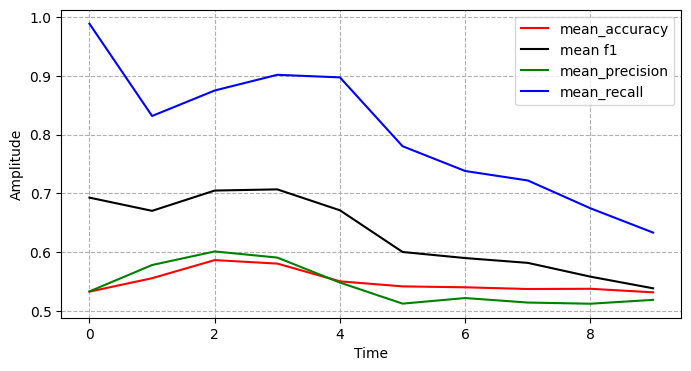

In [56]:
import matplotlib.pyplot as plt

print(f"Mean Accuracy:  {mean_accuracy[-1]:.3f}")
print(f"Mean F1 Score:  {mean_f1[-1]:.3f}")
print(f"Mean Precision: {mean_precision[-1]:.3f}")
print(f"Mean Recall:    {mean_recall[-1]:.3f}")

# Running Test Predictions
plt.figure(figsize=(8, 4))
plt.plot(mean_accuracy, color = "red",label=f"mean_accuracy")
plt.plot(mean_f1, color = "black",label=f"mean f1")
plt.plot(mean_precision, color = "green",label=f"mean_precision")
plt.plot(mean_recall, color = "blue",label=f"mean_recall")
plt.legend()#loc='lower right')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.grid(which='major', linestyle='--', axis='both')

plt.show()